# IS 4487 Lab 7

## Outline

Begin where you left on in Lab 6 with the *SuperStore Retail Orders* dataset.
This lab will ask you to do a deeper data exploration

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_07_retailer_eda2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Superstore Data Dictionary

 ORDER VARIABLES:
 - Order ID
 - Order Date
 - Order Year Month - Year and month of the order
 - Order Type - Was the order completed at a store or online? (Retail, Online)
 - Quantity - Quantity ordered for the product

 CUSTOMER VARIABLES:
 - Customer Name
 - City
 - State Province
 - Email

PRODUCT VARIABLES:
 - Product Name
 - Product Line - Category of the product (i.e. Bikes Phones)
 - Product Price - Price in US Dollars
 - Product Status - Current status of the product (Active, Inactive)

## Load Libraries

➡️ Assignment Tasks
- Load any necessary libraries

In [35]:
import pandas as pd
import matplotlib as mpl
import sklearn as sl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Import Data into Dataframe

➡️ Assignment Tasks
- Import data from the SuperStore retail dataset into a dataframe (in GitHub go to Labs > DataSets)
- Describe or profile the dataframe

In [55]:
df = pd.read_csv('https://github.com/Stan-Pugsley/is_4487_base/blob/main/Labs/DataSets/superstore_retail_orders.csv?raw=true')
print (df)

       order_id  order_date order_year_month     customer_name  \
0         51188  2023-07-01          2023-07     Audrey Blanco   
1         51187  2023-07-01          2023-07       Isaac Allen   
2         51199  2023-07-02          2023-07        Ian Morgan   
3         51241  2023-07-04          2023-07        Alexa Bell   
4         51297  2023-07-08          2023-07        Casey Diaz   
...         ...         ...              ...               ...   
56038     74084  2024-06-29          2024-06        Ian Rogers   
56039     74062  2024-06-29          2024-06   Marcus Anderson   
56040     74065  2024-06-29          2024-06  Nathaniel Howard   
56041     74038  2024-06-29          2024-06        Robin Sanz   
56042     74110  2024-06-30          2024-06   Mallory Jimenez   

                    city state_province                       email  \
0      North Cherylmouth  New Hampshire     audrey_blanco@email.com   
1             Traceyland  West Virginia       isaac_allen@email.c

In [56]:
#look at the top rows
df.head(10)

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status
0,51188,2023-07-01,2023-07,Audrey Blanco,North Cherylmouth,New Hampshire,audrey_blanco@email.com,Retail,3.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
1,51187,2023-07-01,2023-07,Isaac Allen,Traceyland,West Virginia,isaac_allen@email.com,Online,4.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
2,51199,2023-07-02,2023-07,Ian Morgan,Dylanberg,South Dakota,ian_morgan@email.com,Online,5.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
3,51241,2023-07-04,2023-07,Alexa Bell,Lake Tracytown,Wisconsin,alexa_bell@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
4,51297,2023-07-08,2023-07,Casey Diaz,Byrdchester,Mississippi,casey_diaz@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
5,51319,2023-07-09,2023-07,Troy Rodriguez,South Brendamouth,Ohio,troy_rodriguez@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
6,51357,2023-07-11,2023-07,Natalie Phillips,Rachelburgh,Alabama,natalie_phillips@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
7,51371,2023-07-12,2023-07,Dalton Mitchell,Michaeltown,Virginia,dalton_mitchell@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
8,51424,2023-07-15,2023-07,Timothy James,West Pamela,New York,timothy_james@email.com,Retail,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
9,51452,2023-07-17,2023-07,Fernando Scott,East Maureenbury,South Dakota,fernando_scott@email.com,Retail,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active


In [57]:
#look at last rows
df.tail(10)

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status
56033,74083,2024-06-29,2024-06,Alex Murphy,South William,Missouri,alex_murphy@email.com,Online,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56034,74032,2024-06-29,2024-06,Ashlee Tang,Lake Robin,Hawaii,ashlee_tang@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56035,74063,2024-06-29,2024-06,Carmen Raman,Bellshire,Nevada,carmen_raman@email.com,Online,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56036,74074,2024-06-29,2024-06,Carol Xu,Erichaven,New Hampshire,carol_xu@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56037,74055,NaN,NaN,Francis Ortega,Port Cynthiatown,Washington,francis_ortega@email.com,Online,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56038,74084,2024-06-29,2024-06,Ian Rogers,Port Mark,Alabama,ian_rogers@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56039,74062,2024-06-29,2024-06,Marcus Anderson,West Aprilfurt,Nebraska,marcus_anderson@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56040,74065,2024-06-29,2024-06,Nathaniel Howard,New Lindaview,Illinois,nathaniel_howard@email.com,Online,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56041,74038,2024-06-29,2024-06,Robin Sanz,West Frankhaven,Arkansas,robin_sanz@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
56042,74110,2024-06-30,2024-06,Mallory Jimenez,Dillonhaven,Maryland,mallory_jimenez@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active


In [58]:
#get a summary of the dataset
df.describe()

,order_id,quantity,product_price
count,56043.000000,56004.000000,56043.000000
mean,61668.410578,3.348582,6198.309433
std,7508.142486,422.654112,35784.965255
min,45079.000000,1.000000,2.290000
25%,55644.500000,1.000000,7.950000
50%,61870.000000,1.000000,475.600000
75%,68097.000000,2.000000,914.620000
max,74147.000000,100000.000000,235481.000000


In [59]:
#look at the datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56043 entries, 0 to 56042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56043 non-null  int64  
 1   order_date        56011 non-null  object 
 2   order_year_month  56011 non-null  object 
 3   customer_name     56043 non-null  object 
 4   city              55569 non-null  object 
 5   state_province    55569 non-null  object 
 6   email             56043 non-null  object 
 7   order_type        56043 non-null  object 
 8   quantity          56004 non-null  float64
 9   product_name      56043 non-null  object 
 10  product_line      56043 non-null  object 
 11  product_price     56043 non-null  float64
 12  product_status    56043 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 5.6+ MB


## Prepare Data

➡️ Assignment Tasks
- Convert any numbers into the correct datatype if they are not already numeric
- Convert any character variables in to categories if they are appropriate for that datatype
- Check for outliers.   Remove any outliers that appear to be mistakes
- Remove rows with empty (NULL) values
- Identify at least one variable with a missing value that can be imputed.   Fill in those empty values.
- Add a "total_amount" variable based on the quantity and price

In [60]:
# Convert numeric columns to the correct data type
for col in ['quantity', 'product_price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [61]:
# Convert character columns to category type where appropriate
for col in ['order_type', 'product_line', 'product_status', 'city', 'state_province']:
    if col in df.columns:  # Check if the column exists
        df[col] = df[col].astype('category')

In [62]:
# Check for outliers in 'quantity' and 'product_price'
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

df = remove_outliers(df, 'quantity')
df = remove_outliers(df, 'product_price')

In [63]:
# Remove rows with empty (NULL) values
df = df.dropna()

In [64]:
# Check for columns with missing values
print(df.isnull().sum())

# Impute missing values in 'product_price' with the mean
if 'product_price' in df.columns and df['product_price'].isnull().any():
    mean_price = df['product_price'].mean()
    df['product_price'].fillna(mean_price, inplace=True)
    print("Missing 'product_price' values imputed with the mean:", mean_price)

# You can similarly impute other columns if needed, for example 'quantity'
if 'quantity' in df.columns and df['quantity'].isnull().any():
    mean_quantity = df['quantity'].mean()
    df['quantity'].fillna(mean_quantity, inplace=True)
    print("Missing 'quantity' values imputed with the mean:", mean_quantity)

order_id            0
order_date          0
order_year_month    0
customer_name       0
city                0
state_province      0
email               0
order_type          0
quantity            0
product_name        0
product_line        0
product_price       0
product_status      0
dtype: int64


In [65]:
# Calculate total amount
df['total_amount'] = df['quantity'] * df['product_price']

## Prepare Data - Continued

➡️ Assignment Tasks
- Create a variable called "complete_customer_info".   Use "1" for True and "2" for False.  All customer fields must be valid and not empty before this variable is True.
- Create a bar chart showing the count of customers with complete informaiton versus incomplete information

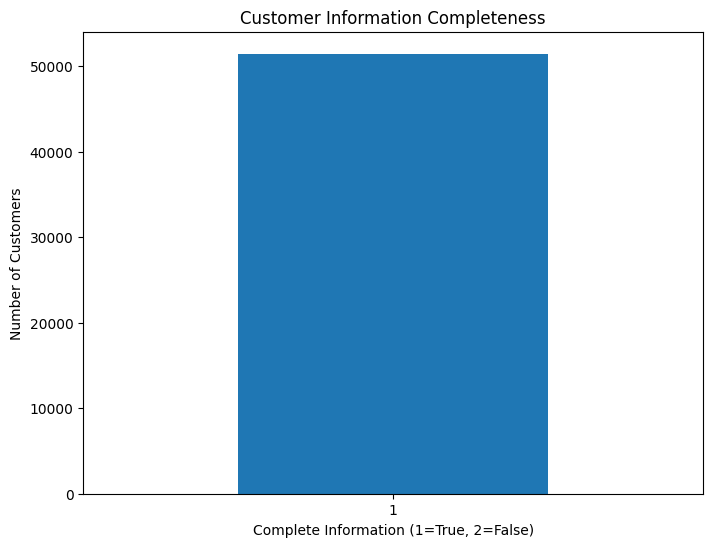

In [66]:
# Assuming 'Customer Name', 'City', 'State Province', and 'Email' are customer fields.
df['complete_customer_info'] = 1  # Initialize to 1 (True)

# Find rows with missing or empty customer information
missing_customer_info = df[df['customer_name'].isnull() |
                           df['city'].isnull() |
                           df['state_province'].isnull() |
                           df['email'].isnull()]

# Set 'complete_customer_info' to 2 (False) for those rows
df.loc[missing_customer_info.index, 'complete_customer_info'] = 2

# Create a bar chart
plt.figure(figsize=(8, 6))
df['complete_customer_info'].value_counts().plot(kind='bar')
plt.title('Customer Information Completeness')
plt.xlabel('Complete Information (1=True, 2=False)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

## Prepare Data - Continued

➡️ Assignment Tasks
- Create seasonal buckets for Winter, Spring, Summer, Fall
- Create a chart to show revenue by season
- Create a chart to show revenue by year

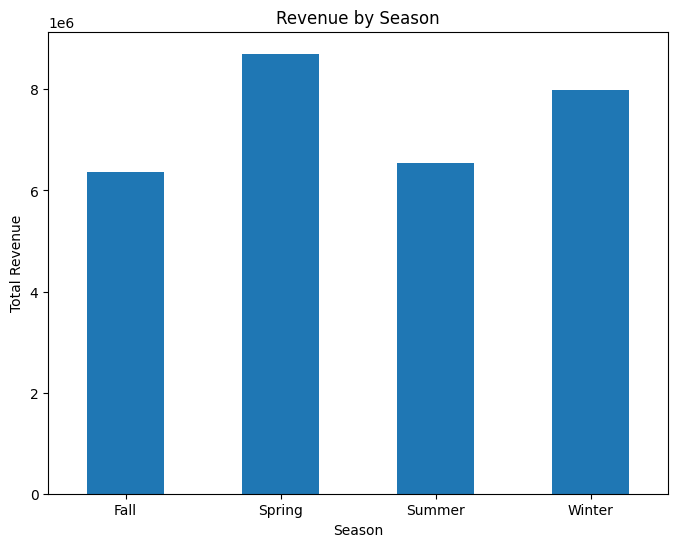

In [67]:
# Create a chart to show revenue by season

# Convert 'Order Date' to datetime objects, specifying the format and coercing errors
df['order_date'] = pd.to_datetime(df['order_date'], format='%Y-%m-%d', errors='coerce')

# Extract the month from the 'Order Date'
df['month'] = df['order_date'].dt.month

# Create seasonal buckets
def assign_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(assign_season)

# Calculate revenue by season
revenue_by_season = df.groupby('season')['total_amount'].sum()

# Create a bar chart for revenue by season
plt.figure(figsize=(8, 6))
revenue_by_season.plot(kind='bar')
plt.title('Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

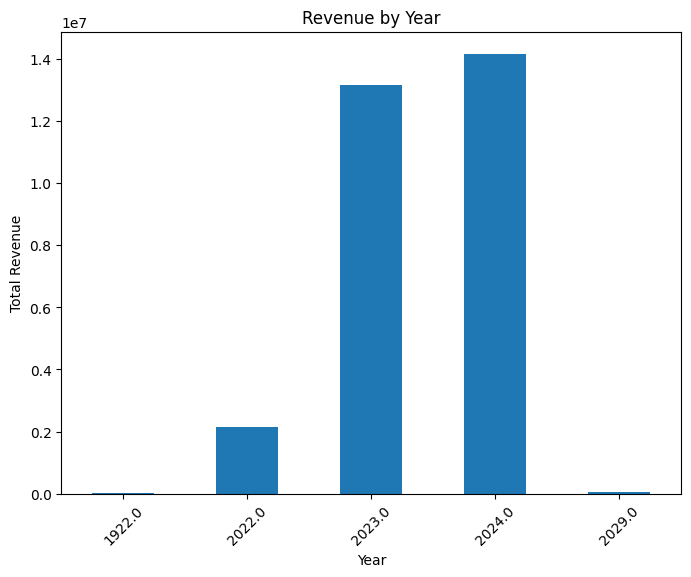

In [68]:
# Create a chart to show revenue by year
# Extract the year from the 'Order Date'
df['year'] = df['order_date'].dt.year

# Calculate revenue by year
revenue_by_year = df.groupby('year')['total_amount'].sum()

# Create a bar chart for revenue by year
plt.figure(figsize=(8, 6))
revenue_by_year.plot(kind='bar')
plt.title('Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## Prepare Data - Continued

➡️ Assignment Tasks
- Create a variable that will group product lines into "Outdoor" versus "Indoor" products.
- Create a plot to show the correlation between outdoor/indoor versus season  

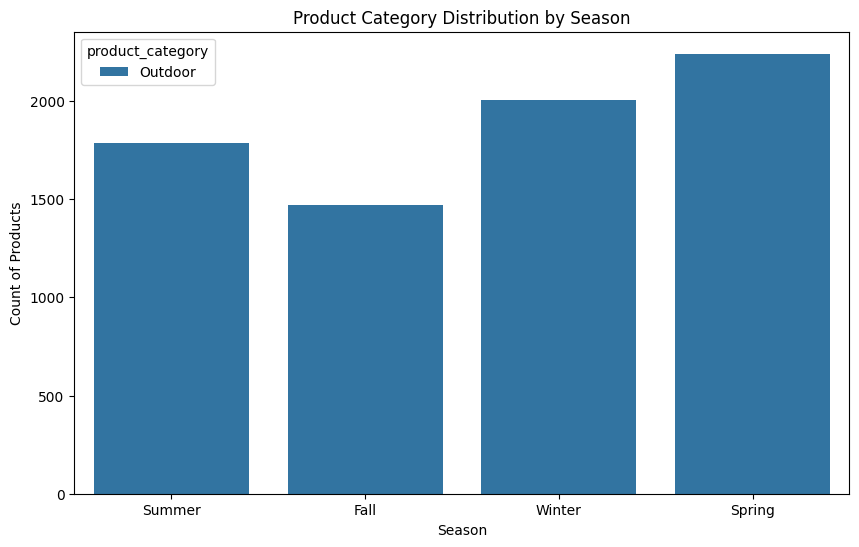

In [52]:
# Create a plot to show the correlation between outdoor/indoor versus season

# Create a mapping for product lines to indoor/outdoor categories
product_line_mapping = {
    'Camping Equipment': 'Outdoor',
    'Golf Equipment': 'Outdoor',
    'Mountaineering Equipment': 'Outdoor',
    'Outdoor Protection': 'Outdoor',
    'Bikes': 'Outdoor',
    'Phone Accessories': 'Indoor',
    'Audio Devices': 'Indoor',
    'Smartphones': 'Indoor',
    'Televisions': 'Indoor',
    'Video Games': 'Indoor'
}

# Apply the mapping to create the 'product_category' column
df['product_category'] = df['product_line'].map(product_line_mapping)

# Create the plot
plt.figure(figsize=(10, 6))
sns.countplot(x='season', hue='product_category', data=df)
plt.title('Product Category Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Count of Products')
plt.show()